# 04 - Web Scraping: Finanznachrichten (Investing.com, RSS Feeds, Reddit)

**Ziel:** Finanznachrichten aus drei verschiedenen Web-Quellen laden als zweite Nachrichtenquelle neben EODHD.

**Quellen:**
1. **Investing.com** - Forex-Nachrichten (Web Scraping mit BeautifulSoup)
2. **RSS Feeds** - Reuters, MarketWatch, FXStreet (feedparser)
3. **Reddit** - r/Forex, r/investing (JSON API)

**Wichtig:** Web Scraping ist abhaengig von der Seitenstruktur und kann sich aendern.

---

## 1. Setup und Imports

In [17]:
# Bibliotheken importieren
import requests
from bs4 import BeautifulSoup
import feedparser
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
import json
from datetime import datetime, timedelta

# Darstellung konfigurieren
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

# User-Agent Header (wichtig fuer Web Scraping)
HEADERS = {
    'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
}

print('Setup erfolgreich!')

Setup erfolgreich!


---
## 2. Quelle 1: RSS Feeds (zuverlaessigste Methode)

RSS Feeds sind die zuverlaessigste Scraping-Methode, da sie strukturiert und stabil sind.

**Feeds:**
- MarketWatch: Devisen/Forex-Nachrichten
- FXStreet: Forex News
- Investing.com RSS: Forex
- Reuters: Business News

In [18]:
# RSS Feed URLs fuer Forex/Finanznachrichten
RSS_FEEDS = {
    'ForexLive': 'https://www.forexlive.com/feed',
    'DailyFX': 'https://www.dailyfx.com/feeds/market-news',
    'FXStreet_News': 'https://www.fxstreet.com/rss/news',
    'Yahoo_Finance': 'https://finance.yahoo.com/news/rssindex',
    'Google_News_Forex': 'https://news.google.com/rss/search?q=forex+EUR+USD&hl=en&gl=US&ceid=US:en',
}

print(f'{len(RSS_FEEDS)} RSS Feeds konfiguriert:')
for name, url in RSS_FEEDS.items():
    print(f'  - {name}')

5 RSS Feeds konfiguriert:
  - ForexLive
  - DailyFX
  - FXStreet_News
  - Yahoo_Finance
  - Google_News_Forex


In [19]:
# Debug: Testen warum RSS Feeds fehlschlagen
import feedparser

test_url = 'https://news.google.com/rss/search?q=forex+EUR+USD&hl=en&gl=US&ceid=US:en'
print(f'Teste: {test_url}')

feed = feedparser.parse(test_url)
print(f'Bozo: {feed.bozo}')
if feed.bozo:
    print(f'Bozo Exception: {feed.bozo_exception}')
print(f'Status: {feed.get("status", "kein Status")}')
print(f'Entries: {len(feed.entries)}')

# Alternativ: direkt mit requests laden
response = requests.get(test_url, headers=HEADERS, timeout=10)
print(f'\nHTTP Status: {response.status_code}')
print(f'Content-Type: {response.headers.get("content-type", "?")}')
print(f'Content Laenge: {len(response.text)} Zeichen')
print(f'Erste 200 Zeichen: {response.text[:200]}')

Teste: https://news.google.com/rss/search?q=forex+EUR+USD&hl=en&gl=US&ceid=US:en
Bozo: True
Bozo Exception: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1000)>
Status: kein Status
Entries: 0

HTTP Status: 200
Content-Type: application/xml; charset=utf-8
Content Laenge: 188619 Zeichen
Erste 200 Zeichen: <?xml version="1.0" encoding="UTF-8" standalone="yes"?><rss version="2.0" xmlns:media="http://search.yahoo.com/mrss/"><channel><generator>NFE/5.0</generator><title>"forex EUR USD" - Google News</title


In [20]:
def scrape_rss_feed(feed_name, feed_url):
    """
    Laedt Artikel aus einem RSS Feed.
    Nutzt requests zum Laden (SSL-Fix) und feedparser zum Parsen.
    """
    print(f'Lade {feed_name}...')
    
    try:
        # Mit requests laden (umgeht SSL-Problem von feedparser)
        response = requests.get(feed_url, headers=HEADERS, timeout=10)
        
        if response.status_code != 200:
            print(f'  WARNUNG: HTTP {response.status_code}')
            return []
        
        # feedparser parst den XML-Text
        feed = feedparser.parse(response.text)
        
        articles = []
        for entry in feed.entries:
            article = {
                'source': feed_name,
                'title': entry.get('title', ''),
                'link': entry.get('link', ''),
                'published': entry.get('published', entry.get('updated', '')),
                'summary': entry.get('summary', entry.get('description', '')),
            }
            
            # HTML-Tags aus Summary entfernen
            if article['summary']:
                soup = BeautifulSoup(article['summary'], 'html.parser')
                article['summary'] = soup.get_text(strip=True)
            
            articles.append(article)
        
        print(f'  -> {len(articles)} Artikel geladen')
        return articles
        
    except Exception as e:
        print(f'  FEHLER: {e}')
        return []

print('Funktion definiert.')

Funktion definiert.


In [21]:
# Alle RSS Feeds laden
rss_articles = []

for feed_name, feed_url in RSS_FEEDS.items():
    articles = scrape_rss_feed(feed_name, feed_url)
    rss_articles.extend(articles)
    time.sleep(1)  # Hoefliche Pause zwischen Requests

# In DataFrame umwandeln
if rss_articles:
    df_rss = pd.DataFrame(rss_articles)
    
    # Datum parsen (verschiedene Formate moeglich)
    df_rss['date'] = pd.to_datetime(df_rss['published'], errors='coerce', utc=True)
    df_rss['date_only'] = df_rss['date'].dt.date
    
    print(f'\nGesamt: {len(df_rss)} Artikel aus RSS Feeds')
    print(f'\nArtikel pro Quelle:')
    print(df_rss['source'].value_counts())
else:
    df_rss = pd.DataFrame()
    print('Keine RSS-Artikel geladen.')

Lade ForexLive...
  -> 25 Artikel geladen
Lade DailyFX...
  WARNUNG: HTTP 403
Lade FXStreet_News...
  -> 30 Artikel geladen
Lade Yahoo_Finance...
  -> 42 Artikel geladen
Lade Google_News_Forex...
  -> 102 Artikel geladen

Gesamt: 199 Artikel aus RSS Feeds

Artikel pro Quelle:
source
Google_News_Forex    102
Yahoo_Finance         42
FXStreet_News         30
ForexLive             25
Name: count, dtype: int64


In [22]:
# RSS Daten anschauen
if not df_rss.empty:
    print('Spalten:', list(df_rss.columns))
    print(f'Zeitraum: {df_rss["date"].min()} bis {df_rss["date"].max()}')
    print(f'\nBeispiel-Artikel:')
    for i, row in df_rss.head(5).iterrows():
        print(f'  [{row["source"]}] {row["title"][:80]}')

Spalten: ['source', 'title', 'link', 'published', 'summary', 'date', 'date_only']
Zeitraum: 2025-09-10 07:00:00+00:00 bis 2026-03-04 12:03:55+00:00

Beispiel-Artikel:
  [ForexLive] Indian Rupee tumbles to a new record low amid the US-Iran war. What's next?
  [ForexLive] Brent crude oil could exceed $100 if Strait of Hormuz closure persists - UBS
  [ForexLive] Iran operatives have secretly made offer to discuss terms for ending the war - N
  [ForexLive] Gold fails to provide shelter amid risk aversion; de-escalation to trigger anoth
  [ForexLive] US futures pare losses, turn positive on the day


---
## 3. Quelle 2: Investing.com (Web Scraping)

**Hinweis:** Investing.com hat Anti-Scraping-Massnahmen. Falls der direkte Scraping-Ansatz blockiert wird, nutzen wir den RSS Feed als Fallback (bereits in Quelle 1 enthalten).

In [23]:
def scrape_investing_com(pages=3):
    """
    Versucht Forex-News von Investing.com zu scrapen.
    Falls blockiert, wird der Fehler dokumentiert (Teil der Datenqualitaetsanalyse).
    """
    articles = []
    base_url = 'https://www.investing.com/news/forex-news'
    
    for page in range(1, pages + 1):
        url = f'{base_url}/{page}' if page > 1 else base_url
        print(f'Lade Seite {page}: {url}')
        
        try:
            response = requests.get(url, headers=HEADERS, timeout=10)
            print(f'  HTTP Status: {response.status_code}')
            
            if response.status_code == 403:
                print('  -> Zugriff verweigert (Anti-Scraping). Wird dokumentiert.')
                continue
            
            if response.status_code != 200:
                print(f'  -> Fehler: HTTP {response.status_code}')
                continue
            
            soup = BeautifulSoup(response.text, 'html.parser')
            
            # Artikel-Elemente suchen (Struktur kann sich aendern!)
            article_elements = soup.find_all('article') or soup.find_all('div', class_=lambda x: x and 'article' in x.lower() if x else False)
            
            if not article_elements:
                # Alternativer Selektor
                article_elements = soup.find_all('a', {'data-test': 'article-title-link'})
            
            for el in article_elements:
                title_tag = el.find('a') if el.name != 'a' else el
                if title_tag:
                    title = title_tag.get_text(strip=True)
                    link = title_tag.get('href', '')
                    if link and not link.startswith('http'):
                        link = 'https://www.investing.com' + link
                    
                    # Datum suchen
                    date_tag = el.find('time') or el.find('span', class_=lambda x: x and 'date' in x.lower() if x else False)
                    date_str = date_tag.get('datetime', date_tag.get_text(strip=True)) if date_tag else ''
                    
                    if title:
                        articles.append({
                            'source': 'Investing.com',
                            'title': title,
                            'link': link,
                            'published': date_str,
                            'summary': '',
                        })
            
            print(f'  -> {len(article_elements)} Elemente gefunden')
            time.sleep(2)  # Hoefliche Pause
            
        except requests.exceptions.Timeout:
            print('  -> Timeout. Investing.com antwortet nicht.')
        except Exception as e:
            print(f'  -> Fehler: {e}')
    
    return articles

print('Funktion definiert.')

Funktion definiert.


In [24]:
# Investing.com scrapen
investing_articles = scrape_investing_com(pages=3)

if investing_articles:
    df_investing = pd.DataFrame(investing_articles)
    df_investing['date'] = pd.to_datetime(df_investing['published'], errors='coerce', utc=True)
    df_investing['date_only'] = df_investing['date'].dt.date
    print(f'\nGesamt: {len(df_investing)} Artikel von Investing.com')
else:
    df_investing = pd.DataFrame()
    print('\nKeine Artikel von Investing.com geladen.')
    print('-> Dies ist erwartbar wegen Anti-Scraping-Massnahmen.')
    print('-> Investing.com RSS Feed wurde bereits in Quelle 1 geladen.')

Lade Seite 1: https://www.investing.com/news/forex-news
  HTTP Status: 403
  -> Zugriff verweigert (Anti-Scraping). Wird dokumentiert.
Lade Seite 2: https://www.investing.com/news/forex-news/2
  HTTP Status: 403
  -> Zugriff verweigert (Anti-Scraping). Wird dokumentiert.
Lade Seite 3: https://www.investing.com/news/forex-news/3
  HTTP Status: 403
  -> Zugriff verweigert (Anti-Scraping). Wird dokumentiert.

Keine Artikel von Investing.com geladen.
-> Dies ist erwartbar wegen Anti-Scraping-Massnahmen.
-> Investing.com RSS Feed wurde bereits in Quelle 1 geladen.


---
## 4. Quelle 3: Reddit (r/Forex, r/investing)

Reddit bietet eine JSON API ohne Authentifizierung. Wir nutzen die .json-Endung an Subreddit-URLs.

**Subreddits:**
- r/Forex - Forex-spezifische Diskussionen
- r/investing - Allgemeine Investment-Diskussionen
- r/economics - Wirtschaftsnachrichten

In [25]:
def scrape_reddit(subreddit, sort='hot', limit=100):
    """
    Laedt Posts von einem Subreddit via JSON API.
    
    Parameter:
        subreddit (str): Name des Subreddits (ohne r/)
        sort (str): Sortierung: 'hot', 'new', 'top'
        limit (int): Anzahl Posts (max 100 pro Request)
    """
    print(f'Lade r/{subreddit} ({sort})...')
    
    url = f'https://www.reddit.com/r/{subreddit}/{sort}.json'
    params = {'limit': limit}
    
    # Reddit braucht einen spezifischen User-Agent
    headers = {'User-Agent': 'DataWrangling-FHNW-Projekt/1.0'}
    
    try:
        response = requests.get(url, headers=headers, params=params, timeout=10)
        print(f'  HTTP Status: {response.status_code}')
        
        if response.status_code == 429:
            print('  -> Rate Limited. Bitte spaeter erneut versuchen.')
            return []
        
        if response.status_code != 200:
            print(f'  -> Fehler: HTTP {response.status_code}')
            return []
        
        data = response.json()
        posts = []
        
        for post in data.get('data', {}).get('children', []):
            p = post['data']
            posts.append({
                'source': f'Reddit_r/{subreddit}',
                'title': p.get('title', ''),
                'link': f'https://www.reddit.com{p.get("permalink", "")}',
                'published': datetime.fromtimestamp(p.get('created_utc', 0)).isoformat(),
                'summary': p.get('selftext', '')[:500],  # Ersten 500 Zeichen
                'score': p.get('score', 0),
                'num_comments': p.get('num_comments', 0),
                'upvote_ratio': p.get('upvote_ratio', 0),
            })
        
        print(f'  -> {len(posts)} Posts geladen')
        return posts
        
    except requests.exceptions.Timeout:
        print('  -> Timeout.')
        return []
    except Exception as e:
        print(f'  -> Fehler: {e}')
        return []

print('Funktion definiert.')

Funktion definiert.


In [26]:
# Reddit Subreddits scrapen
SUBREDDITS = {
    'Forex': ['hot', 'new'],
    'investing': ['hot'],
    'economics': ['hot'],
}

reddit_articles = []

for subreddit, sorts in SUBREDDITS.items():
    for sort in sorts:
        posts = scrape_reddit(subreddit, sort=sort, limit=100)
        reddit_articles.extend(posts)
        time.sleep(2)  # Reddit Rate Limiting beachten

if reddit_articles:
    df_reddit = pd.DataFrame(reddit_articles)
    df_reddit['date'] = pd.to_datetime(df_reddit['published'], errors='coerce', utc=True)
    df_reddit['date_only'] = df_reddit['date'].dt.date
    
    # Duplikate entfernen (gleicher Post in hot + new)
    before = len(df_reddit)
    df_reddit = df_reddit.drop_duplicates(subset='link')
    print(f'\nGesamt: {len(df_reddit)} unique Posts ({before - len(df_reddit)} Duplikate entfernt)')
    print(f'\nPosts pro Subreddit:')
    print(df_reddit['source'].value_counts())
else:
    df_reddit = pd.DataFrame()
    print('Keine Reddit-Posts geladen.')

Lade r/Forex (hot)...
  HTTP Status: 200
  -> 100 Posts geladen
Lade r/Forex (new)...
  HTTP Status: 200
  -> 100 Posts geladen
Lade r/investing (hot)...
  HTTP Status: 200
  -> 100 Posts geladen
Lade r/economics (hot)...
  HTTP Status: 200
  -> 100 Posts geladen

Gesamt: 305 unique Posts (95 Duplikate entfernt)

Posts pro Subreddit:
source
Reddit_r/Forex        105
Reddit_r/investing    100
Reddit_r/economics    100
Name: count, dtype: int64


In [27]:
# Reddit Daten anschauen
if not df_reddit.empty:
    print('Beispiel-Posts:')
    for i, row in df_reddit.head(5).iterrows():
        print(f'  [{row["source"]}] Score:{row["score"]:>5} | {row["title"][:70]}')
    
    print(f'\nStatistiken:')
    print(f'  Durchschnittlicher Score: {df_reddit["score"].mean():.0f}')
    print(f'  Durchschnittliche Kommentare: {df_reddit["num_comments"].mean():.0f}')
    print(f'  Durchschnittliche Upvote-Ratio: {df_reddit["upvote_ratio"].mean():.2f}')

Beispiel-Posts:
  [Reddit_r/Forex] Score:   22 | Are you new here? Want to know where to start? Don't understand why so
  [Reddit_r/Forex] Score:   38 | the moment i realized that it's just mathematical probability of winni
  [Reddit_r/Forex] Score:   29 | How many of you get the ‘Forex isn’t real’ reaction from friends/famil
  [Reddit_r/Forex] Score:   13 | What you think?
  [Reddit_r/Forex] Score:   60 | WhY aLwaYs mE😂

Statistiken:
  Durchschnittlicher Score: 196
  Durchschnittliche Kommentare: 38
  Durchschnittliche Upvote-Ratio: 0.77


---
## 5. Alle Quellen zusammenfuehren

In [28]:
# Gemeinsame Spalten definieren
common_cols = ['source', 'title', 'link', 'published', 'summary', 'date', 'date_only']

# DataFrames zusammenfuehren (nur gemeinsame Spalten)
dfs_to_merge = []

if not df_rss.empty:
    dfs_to_merge.append(df_rss[common_cols])
    print(f'RSS Feeds:      {len(df_rss)} Artikel')

if not df_investing.empty:
    dfs_to_merge.append(df_investing[common_cols])
    print(f'Investing.com:  {len(df_investing)} Artikel')

if not df_reddit.empty:
    # Reddit hat extra Spalten (score, num_comments) - nur gemeinsame nehmen
    dfs_to_merge.append(df_reddit[common_cols])
    print(f'Reddit:         {len(df_reddit)} Posts')

if dfs_to_merge:
    df_all = pd.concat(dfs_to_merge, ignore_index=True)
    print(f'\nGesamt zusammengefuehrt: {len(df_all)} Eintraege')
else:
    df_all = pd.DataFrame()
    print('Keine Daten zum Zusammenfuehren.')

RSS Feeds:      199 Artikel
Reddit:         305 Posts

Gesamt zusammengefuehrt: 504 Eintraege


---
## 6. Datenqualitaetspruefung

In [29]:
if not df_all.empty:
    print('DATENQUALITAET - Web Scraping')
    print('=' * 60)
    print(f'\nGesamtzahl Eintraege: {len(df_all)}')
    print(f'Quellen: {df_all["source"].nunique()}')
    
    # Fehlende Werte
    print(f'\nFehlende Werte:')
    missing = df_all.isnull().sum()
    for col in df_all.columns:
        pct = missing[col] / len(df_all) * 100
        print(f'  {col}: {missing[col]} ({pct:.1f}%)')
    
    # Leere Strings zaehlen
    print(f'\nLeere Strings:')
    for col in ['title', 'summary']:
        empty = (df_all[col] == '').sum()
        print(f'  {col}: {empty} ({empty/len(df_all)*100:.1f}%)')
    
    # Duplikate (gleicher Titel)
    dupes = df_all.duplicated(subset='title').sum()
    print(f'\nDuplikate (gleicher Titel): {dupes}')
    
    # Zeitraum
    valid_dates = df_all['date'].dropna()
    if len(valid_dates) > 0:
        print(f'\nZeitraum: {valid_dates.min()} bis {valid_dates.max()}')
        print(f'Eintraege ohne gueltiges Datum: {df_all["date"].isna().sum()}')

DATENQUALITAET - Web Scraping

Gesamtzahl Eintraege: 504
Quellen: 7

Fehlende Werte:
  source: 0 (0.0%)
  title: 0 (0.0%)
  link: 0 (0.0%)
  published: 0 (0.0%)
  summary: 0 (0.0%)
  date: 72 (14.3%)
  date_only: 72 (14.3%)

Leere Strings:
  title: 0 (0.0%)
  summary: 160 (31.7%)

Duplikate (gleicher Titel): 1

Zeitraum: 2024-09-26 18:48:09+00:00 bis 2026-03-04 13:08:21+00:00
Eintraege ohne gueltiges Datum: 72


---
## 7. Visualisierung

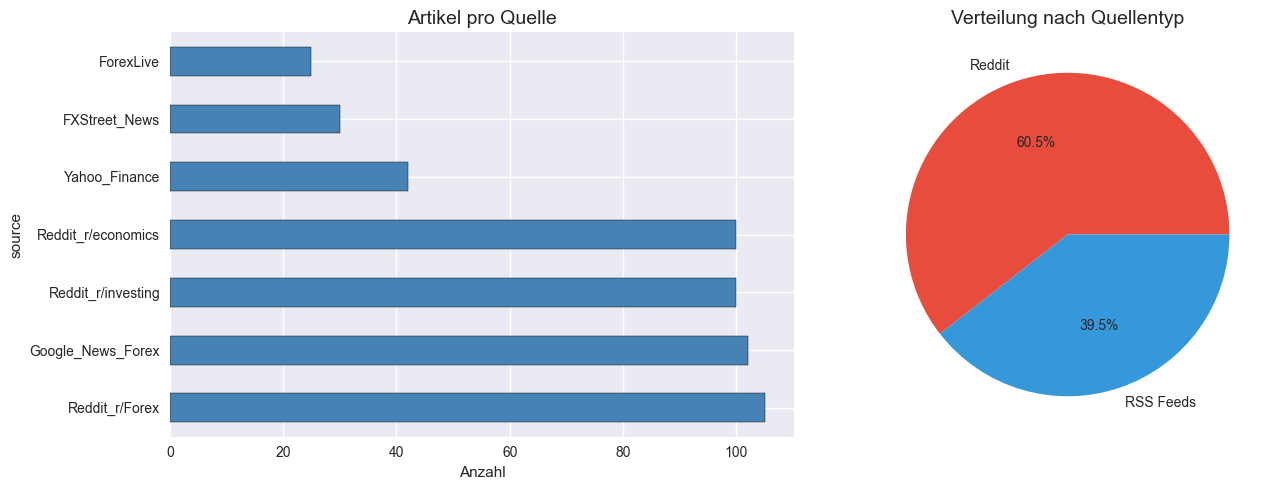

In [30]:
if not df_all.empty:
    # 7.1 Artikel pro Quelle
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Balkendiagramm
    source_counts = df_all['source'].value_counts()
    source_counts.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
    axes[0].set_title('Artikel pro Quelle', fontsize=14)
    axes[0].set_xlabel('Anzahl')
    
    # Pie Chart - Quellentyp bestimmen
    def classify_source(x):
        if 'Reddit' in x:
            return 'Reddit'
        elif x == 'Investing.com':
            return 'Investing.com'
        else:
            return 'RSS Feeds'
    
    source_group = df_all['source'].apply(classify_source).value_counts()
    colors = {'RSS Feeds': '#3498db', 'Reddit': '#e74c3c', 'Investing.com': '#2ecc71'}
    source_group.plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                      colors=[colors.get(s, '#95a5a6') for s in source_group.index])
    axes[1].set_title('Verteilung nach Quellentyp', fontsize=14)
    axes[1].set_ylabel('')
    
    plt.tight_layout()
    plt.show()

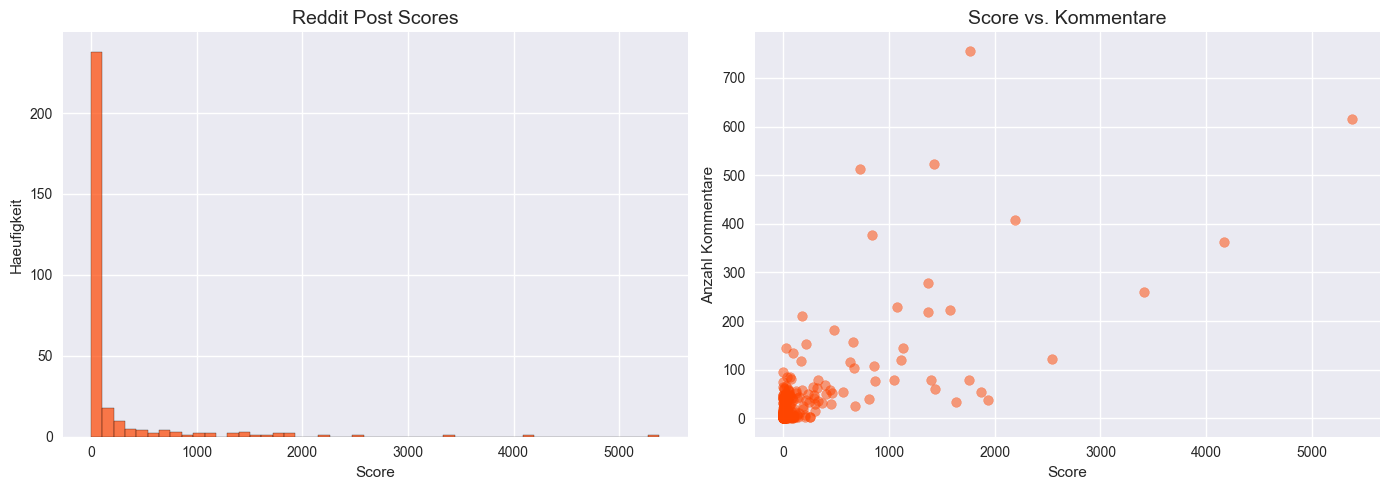

In [31]:
# 7.2 Reddit-spezifische Analyse
if not df_reddit.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Score-Verteilung
    axes[0].hist(df_reddit['score'], bins=50, edgecolor='black', alpha=0.7, color='#FF4500')
    axes[0].set_title('Reddit Post Scores', fontsize=14)
    axes[0].set_xlabel('Score')
    axes[0].set_ylabel('Haeufigkeit')
    
    # Kommentare vs Score
    axes[1].scatter(df_reddit['score'], df_reddit['num_comments'], alpha=0.5, color='#FF4500')
    axes[1].set_title('Score vs. Kommentare', fontsize=14)
    axes[1].set_xlabel('Score')
    axes[1].set_ylabel('Anzahl Kommentare')
    
    plt.tight_layout()
    plt.show()

---
## 8. Rohdaten speichern

In [32]:
# Rohdaten als CSV speichern
OUTPUT_DIR = '../data/raw/news/webscraping'
os.makedirs(OUTPUT_DIR, exist_ok=True)

today = datetime.now().strftime('%Y-%m-%d')

# RSS Feeds
if not df_rss.empty:
    path = os.path.join(OUTPUT_DIR, f'rss_feeds_{today}.csv')
    df_rss.to_csv(path, index=False)
    print(f'Gespeichert: {path} ({len(df_rss)} Artikel)')

# Investing.com
if not df_investing.empty:
    path = os.path.join(OUTPUT_DIR, f'investing_com_{today}.csv')
    df_investing.to_csv(path, index=False)
    print(f'Gespeichert: {path} ({len(df_investing)} Artikel)')

# Reddit
if not df_reddit.empty:
    path = os.path.join(OUTPUT_DIR, f'reddit_forex_{today}.csv')
    df_reddit.to_csv(path, index=False)
    print(f'Gespeichert: {path} ({len(df_reddit)} Posts)')

# Alles zusammen
if not df_all.empty:
    path = os.path.join(OUTPUT_DIR, f'all_scraped_news_{today}.csv')
    df_all.to_csv(path, index=False)
    print(f'\nGesamt gespeichert: {path} ({len(df_all)} Eintraege)')

print('\nAlle Web-Scraping-Rohdaten gespeichert!')

# Auch als JSON speichern
if not df_all.empty:
    json_path = os.path.join(OUTPUT_DIR, f'all_scraped_news_{today}.json')
    df_all.to_json(json_path, orient='records', date_format='iso', force_ascii=False)
    print(f'JSON gespeichert: {json_path}')

Gespeichert: ../data/raw/news/webscraping/rss_feeds_2026-03-04.csv (199 Artikel)
Gespeichert: ../data/raw/news/webscraping/reddit_forex_2026-03-04.csv (305 Posts)

Gesamt gespeichert: ../data/raw/news/webscraping/all_scraped_news_2026-03-04.csv (504 Eintraege)

Alle Web-Scraping-Rohdaten gespeichert!
JSON gespeichert: ../data/raw/news/webscraping/all_scraped_news_2026-03-04.json


---
## 9. Zusammenfassung

### Erkenntnisse:
- **RSS Feeds:** (Ergebnisse eintragen)
- **Investing.com:** (Ergebnisse eintragen - wahrscheinlich blockiert)
- **Reddit:** (Ergebnisse eintragen)
- **Datenqualitaet:** (fehlende Werte, Duplikate, etc.)

### Vergleich mit EODHD News:
- EODHD: Strukturiert, mit Sentiment, historisch
- Web Scraping: Aktuell, verschiedene Perspektiven, aber weniger strukturiert

### Naechste Schritte:
1. Vergleichs-Notebook Yahoo vs. EODHD Forex
2. Datenbereinigung aller Quellen
3. Sentiment-Analyse auf gescrapte Nachrichten anwenden
4. Forex-Kurse mit Sentiment zusammenfuehren